# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [31]:
corpus = """
Deep learning is one of the fastest growing fields of artificial intelligence.
It enables computers to learn complex patterns from large amounts of data.
Recurrent Neural Networks process sequential information by remembering previous inputs.
Long Short-Term Memory networks overcome the limitations of Vanilla RNN by learning long-term dependencies.
Gated Recurrent Units provide similar performance with a simpler architecture and faster training.
Text generation models learn grammar, sentence structure, and contextual relationships to predict meaningful text sequences.
"""

print(corpus)


Deep learning is one of the fastest growing fields of artificial intelligence.
It enables computers to learn complex patterns from large amounts of data.
Recurrent Neural Networks process sequential information by remembering previous inputs.
Long Short-Term Memory networks overcome the limitations of Vanilla RNN by learning long-term dependencies.
Gated Recurrent Units provide similar performance with a simpler architecture and faster training.
Text generation models learn grammar, sentence structure, and contextual relationships to predict meaningful text sequences.



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [32]:
from tensorflow.keras.utils import to_categorical


tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary Size:", total_words)

input_sequences = []

for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = to_categorical(y, num_classes=total_words)

print("Maximum Sequence Length:", max_len)
print("Input Shape (X):", X.shape)
print("Output Shape (y):", y.shape)

Vocabulary Size: 65
Maximum Sequence Length: 16
Input Shape (X): (72, 15)
Output Shape (y): (72, 65)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [33]:
# Model 1: Vanilla RNN
loss='sparse_categorical_crossentropy'

rnn_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=100,
              input_length=max_len - 1), SimpleRNN(128),# Hidden units increased from 64 → 128

    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print(" Vanilla RNN training completed.")

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.0139 - loss: 4.1819
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1250 - loss: 4.0480
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1389 - loss: 3.9510 
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1806 - loss: 3.8606
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2361 - loss: 3.7607
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2500 - loss: 3.6588 
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2778 - loss: 3.5548
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3611 - loss: 3.4283
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4861 - loss: 3.3131 
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5000 - loss: 3.1850
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5000 - loss: 3.0422
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4861 -

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [34]:
# Model 2: LSTM
loss='sparse_categorical_crossentropy'
lstm_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=100,
              input_length=max_len-1),
              LSTM(128),                         # Hidden units increased from 64 → 128

    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM training completed.")

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.0139 - loss: 4.1767  
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0972 - loss: 4.1638
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0694 - loss: 4.1528
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0556 - loss: 4.1410
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0556 - loss: 4.1275
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0556 - loss: 4.1070
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0556 - loss: 4.0753
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0556 - loss: 4.0169    
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0556 - loss: 3.9901
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0556 - loss: 4.0065
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0556 - loss: 3.9383
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.069

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [35]:
# Model 3: GRU
loss='sparse_categorical_crossentropy'
gru_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=100,
        input_length=max_len-1
    ),

    GRU(128), # Hidden units increased from 64 → 128

    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print(" GRU training completed.")

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.0000e+00 - loss: 4.1773
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0556 - loss: 4.1586
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1667 - loss: 4.1441
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1806 - loss: 4.1288
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1667 - loss: 4.1133
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1806 - loss: 4.0942
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1250 - loss: 4.0730
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0972 - loss: 4.0458
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0972 - loss: 4.0056
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0833 - loss: 3.9529
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0833 - loss: 3.9115
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0833 

## 📉 Compare Training Loss

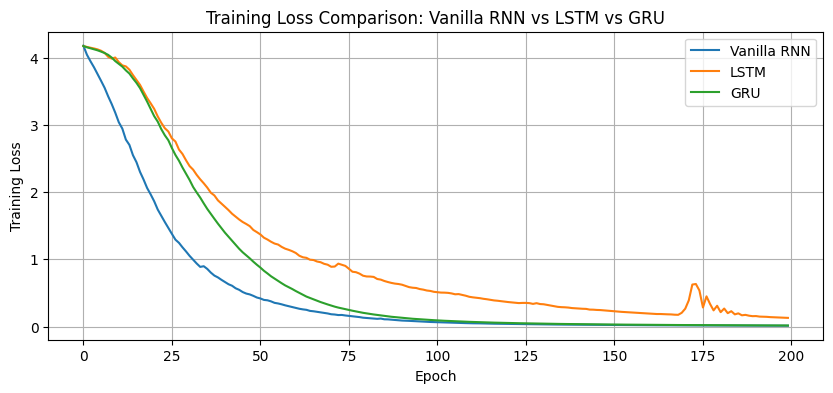

In [36]:
plt.figure(figsize=(10, 4))

plt.plot(rnn_history.history['loss'], label='Vanilla RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison: Vanilla RNN vs LSTM vs GRU")
plt.legend()
plt.grid(True)
plt.show()

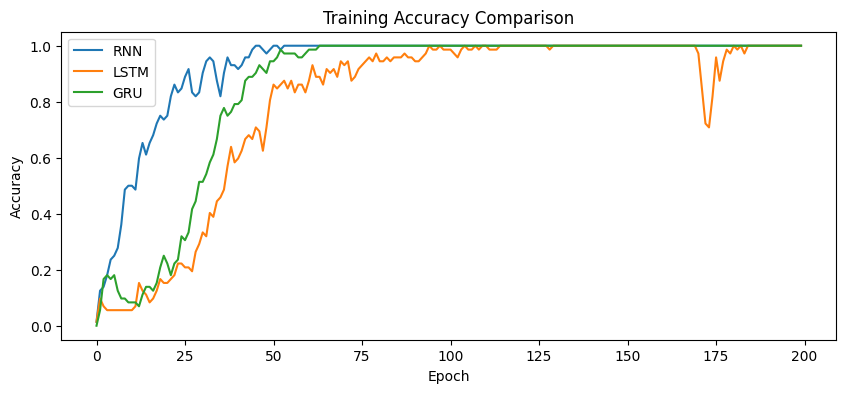

In [39]:
plt.figure(figsize=(10,4))

plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [37]:
def generate_text(model, seed_text, next_words=10):
    """
    Generate text by predicting the next word repeatedly.

    Parameters:
        model: Trained RNN/LSTM/GRU model
        seed_text: Initial text sequence
        next_words: Number of words to generate

    Returns:
        Generated text sequence
    """

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len - 1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

## 🧪 Generate Text Samples

In [38]:
seed_text = "deep learning"

print("Generated Text using Vanilla RNN:")
print(generate_text(rnn_model, seed_text, next_words=10))

print("\nGenerated Text using LSTM:")
print(generate_text(lstm_model, seed_text, next_words=10))

print("\nGenerated Text using GRU:")
print(generate_text(gru_model, seed_text, next_words=10))

Generated Text using Vanilla RNN:
deep learning is one of the fastest growing fields of artificial intelligence

Generated Text using LSTM:
deep learning is one of the fastest growing fields of artificial intelligence

Generated Text using GRU:
deep learning is one of the fastest growing fields of artificial intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**